# Perceptrón para Clusterización y Segmentación de Colores

Implementación del algoritmo del perceptrón siguiendo el pseudocódigo:
- Inicializar pesos y umbral
- Épocas máximas = 100, tasa de aprendizaje = 0.01
- Entrenar actualizando pesos según el error

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D

## 1. Implementación del Perceptrón (siguiendo el pseudocódigo)

In [2]:
class Perceptron:
    """
    Perceptrón simple siguiendo el pseudocódigo:
    0. Inicializar pesos y umbral
    1. epocas_maximas = 100
    2. epoca = 0
    3. tasa_aprendizaje = 0.01
    4. Mientras (epoca < epocas_maximas):
    5.   Para cada instancia de entrenamiento:
    6.     Calcular salida del perceptrón
    7.     Calcular error
    8.     Actualizar pesos y umbral
    9.   epoca += 1
    """
    
    def __init__(self, n_entradas, tasa_aprendizaje=0.01, epocas_maximas=100):
        # Paso 0: Inicializar pesos y umbral (bias)
        self.pesos = np.random.uniform(-0.5, 0.5, n_entradas)
        self.umbral = np.random.uniform(-0.5, 0.5)  # bias
        self.tasa_aprendizaje = tasa_aprendizaje      # Paso 3
        self.epocas_maximas = epocas_maximas            # Paso 1
        self.historial_errores = []
        self.historial_pesos = []
    
    def funcion_activacion(self, suma):
        """Función escalón: retorna 1 si suma >= 0, sino 0"""
        return 1 if suma >= 0 else 0
    
    def predecir(self, entrada):
        """Paso 6: Calcular salida del perceptrón"""
        suma = np.dot(entrada, self.pesos) + self.umbral
        return self.funcion_activacion(suma)
    
    def entrenar(self, X, y):
        """Algoritmo de entrenamiento del perceptrón"""
        epoca = 0  # Paso 2
        
        # Paso 4: Mientras (epoca < epocas_maximas)
        while epoca < self.epocas_maximas:
            errores_epoca = 0
            
            # Paso 5: Para cada instancia de entrenamiento
            for i in range(len(X)):
                # Paso 6: Calcular salida del perceptrón
                salida = self.predecir(X[i])
                
                # Paso 7: Calcular el error
                error = y[i] - salida
                
                # Paso 8: Actualizar pesos y umbral
                if error != 0:
                    self.pesos += self.tasa_aprendizaje * error * X[i]
                    self.umbral += self.tasa_aprendizaje * error
                    errores_epoca += 1
            
            self.historial_errores.append(errores_epoca)
            self.historial_pesos.append(self.pesos.copy())
            
            # Paso 9: epoca += 1
            epoca += 1
            
            # Convergencia temprana
            if errores_epoca == 0:
                print(f"  ¡Convergió en la época {epoca}!")
                break
        
        print(f"  Entrenamiento finalizado. Épocas: {epoca}, Errores finales: {errores_epoca}")
        return self

## 2. Generar Dataset de Colores (RGB normalizado 0-1)

In [3]:
np.random.seed(42)

def generar_colores(n_por_clase=80):
    """Genera muestras de colores en espacio RGB normalizado [0,1]"""
    # Clase 0: Colores CÁLIDOS (rojos, naranjas, amarillos)
    rojos = np.column_stack([
        np.random.uniform(0.6, 1.0, n_por_clase),  # R alto
        np.random.uniform(0.0, 0.4, n_por_clase),  # G bajo
        np.random.uniform(0.0, 0.3, n_por_clase),  # B bajo
    ])
    
    # Clase 1: Colores FRÍOS (azules, verdes)
    azules = np.column_stack([
        np.random.uniform(0.0, 0.3, n_por_clase),  # R bajo
        np.random.uniform(0.1, 0.5, n_por_clase),  # G medio
        np.random.uniform(0.6, 1.0, n_por_clase),  # B alto
    ])
    
    X = np.vstack([rojos, azules])
    y = np.array([0]*n_por_clase + [1]*n_por_clase)
    
    # Mezclar datos
    indices = np.random.permutation(len(X))
    return X[indices], y[indices]

X, y = generar_colores(80)
print(f"Dataset: {X.shape[0]} muestras, {X.shape[1]} características (R, G, B)")
print(f"Clase 0 (Cálidos): {np.sum(y==0)}, Clase 1 (Fríos): {np.sum(y==1)}")

Dataset: 160 muestras, 3 características (R, G, B)
Clase 0 (Cálidos): 80, Clase 1 (Fríos): 80


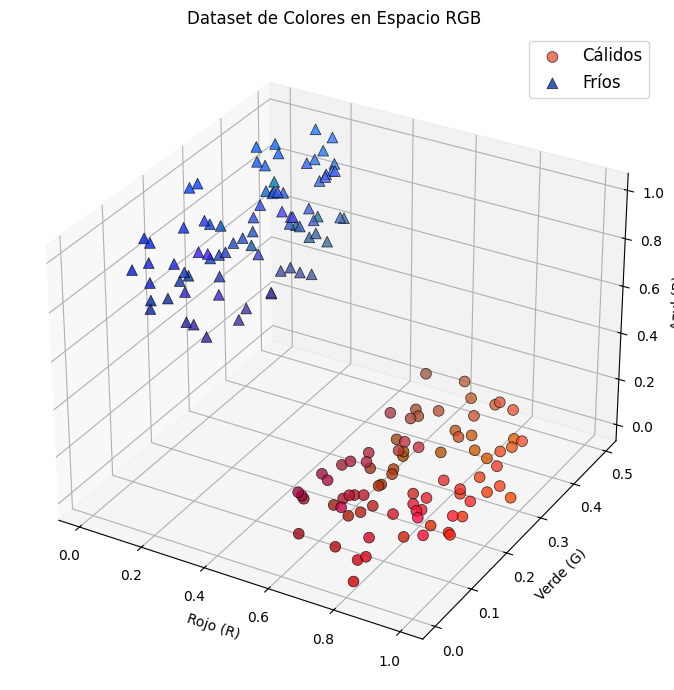

In [4]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for clase, nombre, marker in [(0, 'Cálidos', 'o'), (1, 'Fríos', '^')]:
    mask = y == clase
    colores_rgb = X[mask]
    ax.scatter(colores_rgb[:,0], colores_rgb[:,1], colores_rgb[:,2],
               c=colores_rgb, marker=marker, s=60, edgecolors='black',
               linewidth=0.5, label=nombre, alpha=0.8)

ax.set_xlabel('Rojo (R)')
ax.set_ylabel('Verde (G)')
ax.set_zlabel('Azul (B)')
ax.set_title('Dataset de Colores en Espacio RGB')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 3. Entrenar el Perceptrón

In [5]:
print("=" * 50)
print("ENTRENAMIENTO DEL PERCEPTRÓN")
print("=" * 50)

perceptron = Perceptron(
    n_entradas=3,           # R, G, B
    tasa_aprendizaje=0.01,  # Paso 3 del pseudocódigo
    epocas_maximas=100      # Paso 1 del pseudocódigo
)

perceptron.entrenar(X, y)

print(f"\nPesos finales: R={perceptron.pesos[0]:.4f}, G={perceptron.pesos[1]:.4f}, B={perceptron.pesos[2]:.4f}")
print(f"Umbral (bias): {perceptron.umbral:.4f}")

# Precisión
predicciones = np.array([perceptron.predecir(x) for x in X])
precision = np.mean(predicciones == y) * 100
print(f"Precisión: {precision:.1f}%")

ENTRENAMIENTO DEL PERCEPTRÓN
  ¡Convergió en la época 5!
  Entrenamiento finalizado. Épocas: 5, Errores finales: 0

Pesos finales: R=-0.0006, G=-0.1217, B=0.1979
Umbral (bias): -0.0591
Precisión: 100.0%


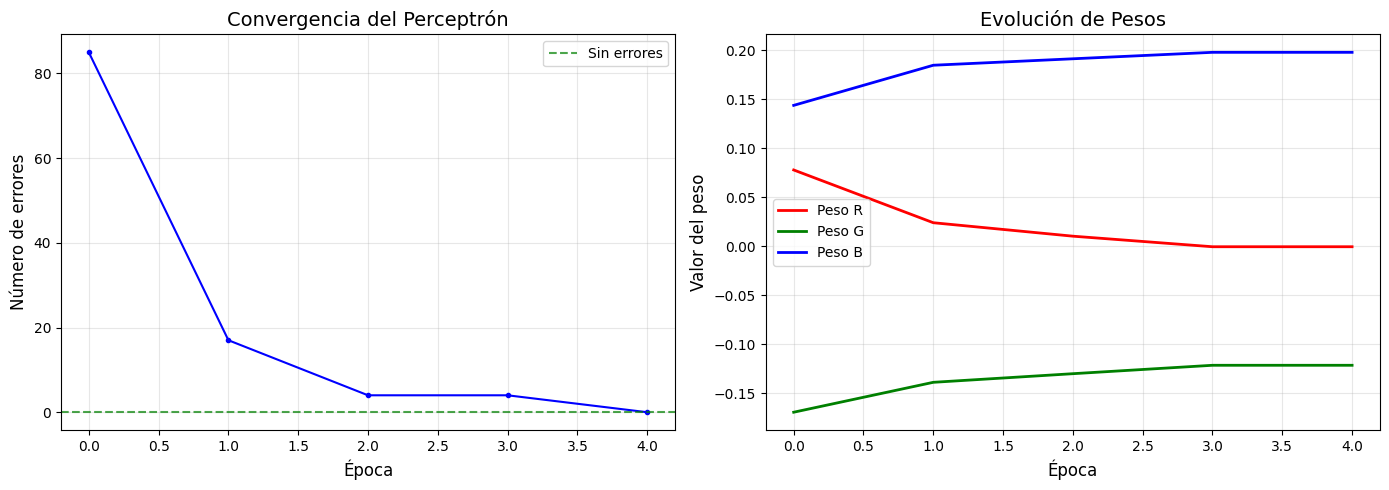

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Errores por época
axes[0].plot(perceptron.historial_errores, 'b-o', markersize=3, linewidth=1.5)
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Número de errores', fontsize=12)
axes[0].set_title('Convergencia del Perceptrón', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='green', linestyle='--', alpha=0.7, label='Sin errores')
axes[0].legend()

# Evolución de pesos
historial = np.array(perceptron.historial_pesos)
axes[1].plot(historial[:, 0], 'r-', label='Peso R', linewidth=2)
axes[1].plot(historial[:, 1], 'g-', label='Peso G', linewidth=2)
axes[1].plot(historial[:, 2], 'b-', label='Peso B', linewidth=2)
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('Valor del peso', fontsize=12)
axes[1].set_title('Evolución de Pesos', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Segmentación de una Imagen Sintética

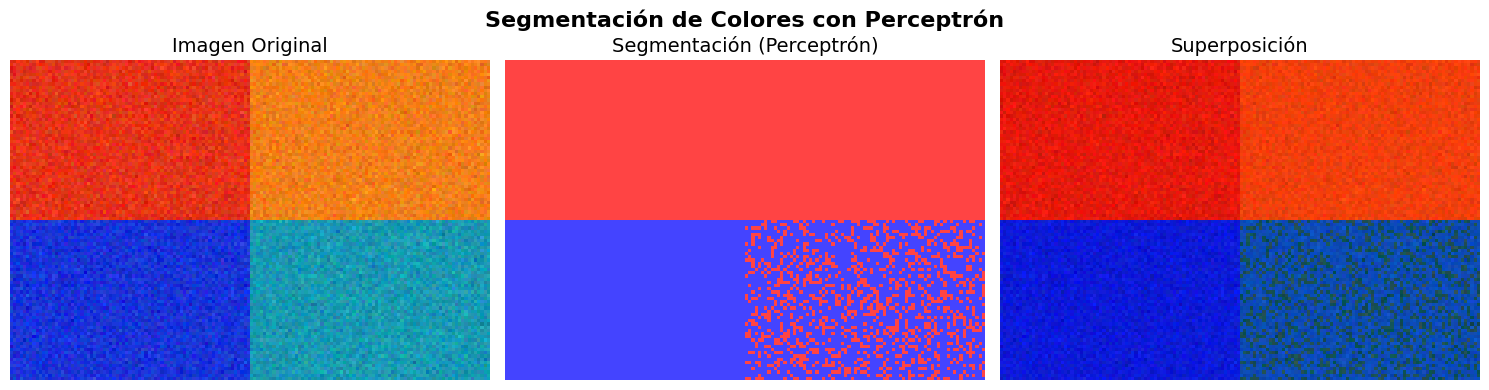

In [7]:
def crear_imagen_prueba(alto=100, ancho=150):
    """Crea una imagen de prueba con zonas cálidas y frías"""
    img = np.zeros((alto, ancho, 3))
    # Zona roja (arriba-izquierda)
    img[0:50, 0:75] = [0.9, 0.2, 0.1]
    # Zona naranja (arriba-derecha)
    img[0:50, 75:150] = [0.95, 0.5, 0.1]
    # Zona azul (abajo-izquierda)
    img[50:100, 0:75] = [0.1, 0.2, 0.85]
    # Zona verde-azul (abajo-derecha)
    img[50:100, 75:150] = [0.1, 0.6, 0.7]
    # Agregar ruido
    ruido = np.random.normal(0, 0.05, img.shape)
    img = np.clip(img + ruido, 0, 1)
    return img

imagen = crear_imagen_prueba()

# Segmentar cada pixel
alto, ancho, _ = imagen.shape
segmentada = np.zeros((alto, ancho))

for i in range(alto):
    for j in range(ancho):
        pixel_rgb = imagen[i, j]
        segmentada[i, j] = perceptron.predecir(pixel_rgb)

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(imagen)
axes[0].set_title('Imagen Original', fontsize=14)
axes[0].axis('off')

# Mapa de segmentación
cmap = ListedColormap(['#FF4444', '#4444FF'])
axes[1].imshow(segmentada, cmap=cmap)
axes[1].set_title('Segmentación (Perceptrón)', fontsize=14)
axes[1].axis('off')

# Superponer
overlay = imagen.copy()
overlay[segmentada == 0] = overlay[segmentada == 0] * [1, 0.5, 0.5]
overlay[segmentada == 1] = overlay[segmentada == 1] * [0.5, 0.5, 1]
axes[2].imshow(overlay)
axes[2].set_title('Superposición', fontsize=14)
axes[2].axis('off')

plt.suptitle('Segmentación de Colores con Perceptrón', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Extensión Multi-clase (One-vs-All)
Para segmentar más de 2 grupos de colores

ENTRENAMIENTO MULTI-CLASE (One-vs-All)

Perceptrón para clase 'Rojos':
  ¡Convergió en la época 6!
  Entrenamiento finalizado. Épocas: 6, Errores finales: 0

Perceptrón para clase 'Verdes':
  ¡Convergió en la época 10!
  Entrenamiento finalizado. Épocas: 10, Errores finales: 0

Perceptrón para clase 'Azules':
  ¡Convergió en la época 6!
  Entrenamiento finalizado. Épocas: 6, Errores finales: 0

Precisión multi-clase: 100.0%


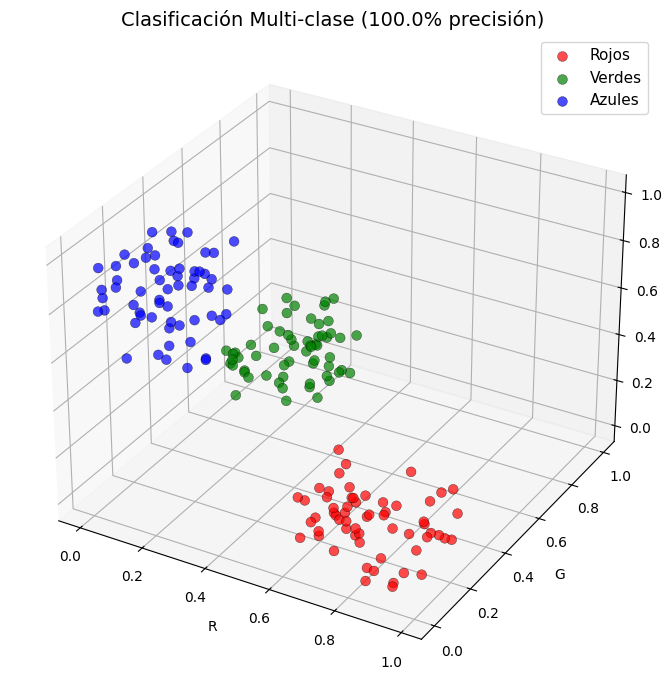

In [8]:
np.random.seed(42)

def generar_multiclase(n=60):
    """3 clases: Rojos, Verdes, Azules"""
    rojos = np.column_stack([
        np.random.uniform(0.6, 1.0, n),
        np.random.uniform(0.0, 0.3, n),
        np.random.uniform(0.0, 0.3, n),
    ])
    verdes = np.column_stack([
        np.random.uniform(0.0, 0.3, n),
        np.random.uniform(0.6, 1.0, n),
        np.random.uniform(0.0, 0.3, n),
    ])
    azules = np.column_stack([
        np.random.uniform(0.0, 0.3, n),
        np.random.uniform(0.0, 0.3, n),
        np.random.uniform(0.6, 1.0, n),
    ])
    X = np.vstack([rojos, verdes, azules])
    y = np.array([0]*n + [1]*n + [2]*n)
    idx = np.random.permutation(len(X))
    return X[idx], y[idx]

X_multi, y_multi = generar_multiclase()
n_clases = 3
nombres_clases = ['Rojos', 'Verdes', 'Azules']

# Entrenar un perceptrón por clase (One-vs-All)
print("=" * 50)
print("ENTRENAMIENTO MULTI-CLASE (One-vs-All)")
print("=" * 50)

perceptrones = []
for c in range(n_clases):
    print(f"\nPerceptrón para clase '{nombres_clases[c]}':")
    y_bin = (y_multi == c).astype(int)
    p = Perceptron(n_entradas=3, tasa_aprendizaje=0.01, epocas_maximas=100)
    p.entrenar(X_multi, y_bin)
    perceptrones.append(p)

# Clasificar: asignar la clase cuyo perceptrón da mayor confianza
def predecir_multiclase(x, perceptrones):
    sumas = [np.dot(x, p.pesos) + p.umbral for p in perceptrones]
    return np.argmax(sumas)

pred_multi = np.array([predecir_multiclase(x, perceptrones) for x in X_multi])
prec_multi = np.mean(pred_multi == y_multi) * 100
print(f"\nPrecisión multi-clase: {prec_multi:.1f}%")

# Visualizar 3D multi-clase
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colores_clase = ['red', 'green', 'blue']
for c in range(n_clases):
    mask = y_multi == c
    ax.scatter(X_multi[mask, 0], X_multi[mask, 1], X_multi[mask, 2],
               c=colores_clase[c], marker='o', s=50, alpha=0.7,
               edgecolors='black', linewidth=0.3, label=nombres_clases[c])

ax.set_xlabel('R'); ax.set_ylabel('G'); ax.set_zlabel('B')
ax.set_title(f'Clasificación Multi-clase ({prec_multi:.1f}% precisión)', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 6. Segmentación Multi-clase en Imagen

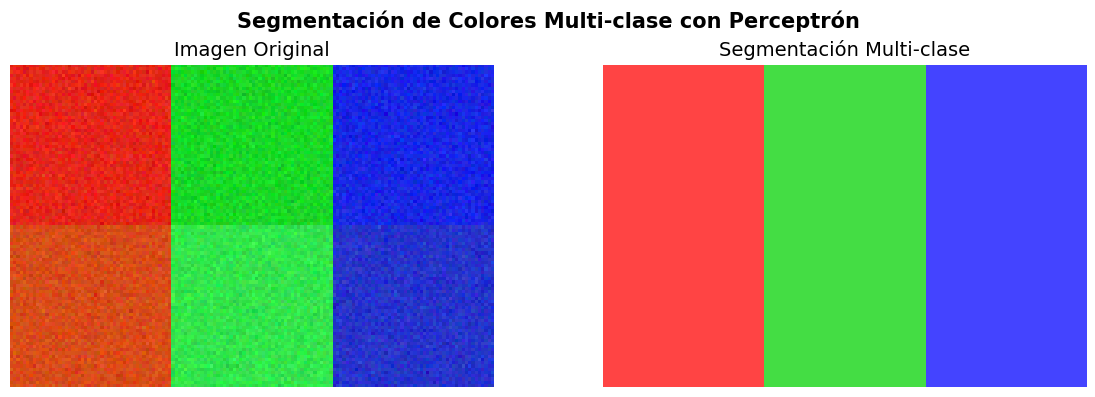


¡Notebook completado exitosamente!


In [9]:
def crear_imagen_multicolor(alto=100, ancho=150):
    img = np.zeros((alto, ancho, 3))
    img[0:50, 0:50]     = [0.9, 0.15, 0.1]   # Rojo
    img[0:50, 50:100]   = [0.1, 0.85, 0.15]   # Verde
    img[0:50, 100:150]  = [0.1, 0.15, 0.9]    # Azul
    img[50:100, 0:50]   = [0.85, 0.3, 0.1]    # Rojo-naranja
    img[50:100, 50:100] = [0.2, 0.9, 0.3]     # Verde claro
    img[50:100, 100:150]= [0.15, 0.2, 0.8]    # Azul oscuro
    ruido = np.random.normal(0, 0.04, img.shape)
    return np.clip(img + ruido, 0, 1)

img_multi = crear_imagen_multicolor()
alto, ancho, _ = img_multi.shape
seg_multi = np.zeros((alto, ancho))

for i in range(alto):
    for j in range(ancho):
        seg_multi[i, j] = predecir_multiclase(img_multi[i, j], perceptrones)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(img_multi)
axes[0].set_title('Imagen Original', fontsize=14)
axes[0].axis('off')

cmap3 = ListedColormap(['#FF4444', '#44DD44', '#4444FF'])
axes[1].imshow(seg_multi, cmap=cmap3)
axes[1].set_title('Segmentación Multi-clase', fontsize=14)
axes[1].axis('off')

plt.suptitle('Segmentación de Colores Multi-clase con Perceptrón', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n¡Notebook completado exitosamente!")